# NBA Underdog Scalp Strategy Backtest

Comprehensive parameter optimization study for the underdog scalp strategy.

**Analysis Goals:**
1. Test entry at every 10th of game time (0%, 10%, 20%... 90%)
2. Analyze EV of betting on underdog at each entry point
3. Parameter search for optimal stop loss and take profit at each time point
4. Find optimal closeness threshold on aggregate

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. Load and Prepare Data

In [4]:
# Load raw EV data
df = pd.read_csv('../data/nba_ev_raw.csv')
print(f"Loaded {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 5,547 rows
Columns: ['event_ticker', 'game_date', 'season', 'title', 'home_team', 'away_team', 'winner', 'minutes_until_settlement', 'home_mid', 'away_mid', 'favorite', 'favorite_price', 'underdog_price', 'favorite_won', 'ev_favorite', 'volume', 'settlement_delay', 'minutes_until_game_end']


,event_ticker,game_date,season,title,home_team,away_team,winner,minutes_until_settlement,home_mid,away_mid,favorite,favorite_price,underdog_price,favorite_won,ev_favorite,volume,settlement_delay,minutes_until_game_end
0,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,10,0.500,0.500,home,0.500,0.500,1,0.500,1071,10,0
1,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,20,0.995,0.005,home,0.995,0.005,1,0.005,2730,10,10
2,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,30,0.995,0.005,home,0.995,0.005,1,0.005,20243,10,20
3,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,40,0.995,0.005,home,0.995,0.005,1,0.005,7281,10,30
4,KXNBAGAME-26JAN26GSWMIN,2026-01-27 05:05:27.039639+00:00,2025-26,Golden State at Minnesota Winner?,Minnesota,Golden State,home,50,0.965,0.035,home,0.965,0.035,1,0.035,43945,10,40


In [5]:
# Check data structure
print(f"Unique games: {df['event_ticker'].nunique()}")
print(f"Minutes range: {df['minutes_until_game_end'].min()} to {df['minutes_until_game_end'].max()}")
print(f"\nSample per game:")
df.groupby('event_ticker').size().describe()

Unique games: 155
Minutes range: 0 to 360

Sample per game:


count    155.000000
mean      35.787097
std        0.764361
min       32.000000
25%       35.000000
50%       36.000000
75%       36.000000
max       37.000000
dtype: float64

In [6]:
# NBA game is ~48 minutes, normalize to game_pct (0% = start, 100% = end)
# minutes_until_game_end: 0 = game over, higher = earlier in game
TOTAL_GAME_MINUTES = 48

# Create game_pct: what % of game has elapsed
# If minutes_until_game_end = 48, game_pct = 0% (just started)
# If minutes_until_game_end = 0, game_pct = 100% (ended)
df['game_pct'] = 100 * (1 - df['minutes_until_game_end'] / TOTAL_GAME_MINUTES)
df['game_pct'] = df['game_pct'].clip(0, 100)

# Game decile (0-9)
df['game_decile'] = (df['game_pct'] // 10).astype(int).clip(0, 9)

print(f"Game % range: {df['game_pct'].min():.1f}% to {df['game_pct'].max():.1f}%")
print(f"\nDecile distribution:")
df.groupby('game_decile').size()

Game % range: 0.0% to 100.0%

Decile distribution:


game_decile
0    4773
1     155
3     155
5     155
7     154
9     155
dtype: int64

In [7]:
# Identify underdog at each time point
# underdog_price is already provided, but let's verify
df['underdog_won'] = ~df['favorite_won'].astype(bool)

# closeness metric: how close is the game?
# If favorite_price near 0.5, game is very close
# closeness = 1 - |favorite_price - 0.5| / 0.5 = 1 - |2*fav - 1|
df['closeness'] = 1 - np.abs(2 * df['favorite_price'] - 1)

print(f"Underdog win rate: {df.groupby('event_ticker')['underdog_won'].first().mean():.1%}")
print(f"\nCloseness distribution:")
df['closeness'].describe()

Underdog win rate: 25.2%

Closeness distribution:


count    5547.000000
mean        0.596066
std         0.278878
min         0.010000
25%         0.370000
50%         0.640000
75%         0.830000
max         1.000000
Name: closeness, dtype: float64

## 2. Build Price Trajectories Per Game

In [8]:
@dataclass
class GameTrajectory:
    """Full price trajectory for a single game."""
    event_ticker: str
    home_team: str
    away_team: str
    winner: str  # 'home' or 'away'
    # Dict mapping game_pct (0-100) to prices
    prices: Dict[int, Dict[str, float]]  # {game_pct: {'favorite_price', 'underdog_price', 'closeness'}}

def build_trajectories(df: pd.DataFrame) -> List[GameTrajectory]:
    """Build price trajectories for each game."""
    trajectories = []
    
    for event_ticker, group in df.groupby('event_ticker'):
        # Sort by game progress
        group = group.sort_values('game_pct')
        
        # Get game info from first row
        first = group.iloc[0]
        winner = 'home' if first['favorite'] == 'home' and first['favorite_won'] else \
                 'away' if first['favorite'] == 'away' and first['favorite_won'] else \
                 'home' if first['favorite'] == 'away' and not first['favorite_won'] else 'away'
        
        # Correct: who won based on favorite_won
        if first['favorite_won']:
            winner = first['favorite']
        else:
            winner = 'home' if first['favorite'] == 'away' else 'away'
        
        # Build price dict
        prices = {}
        for _, row in group.iterrows():
            pct = int(row['game_pct'])
            prices[pct] = {
                'favorite_price': row['favorite_price'],
                'underdog_price': row['underdog_price'],
                'closeness': row['closeness'],
                'favorite': row['favorite'],
            }
        
        traj = GameTrajectory(
            event_ticker=event_ticker,
            home_team=first['home_team'],
            away_team=first['away_team'],
            winner=winner,
            prices=prices,
        )
        trajectories.append(traj)
    
    return trajectories

trajectories = build_trajectories(df)
print(f"Built {len(trajectories)} game trajectories")

Built 155 game trajectories


In [9]:
# Example trajectory
t = trajectories[0]
print(f"Game: {t.away_team} @ {t.home_team}")
print(f"Winner: {t.winner}")
print(f"Price points: {len(t.prices)}")
print(f"\nFirst 5 time points:")
for pct in sorted(t.prices.keys())[:5]:
    p = t.prices[pct]
    print(f"  {pct}%: fav={p['favorite_price']:.3f} underdog={p['underdog_price']:.3f} closeness={p['closeness']:.3f}")

Game: Cleveland @ Indiana
Winner: away
Price points: 6

First 5 time points:
  0%: fav=0.670 underdog=0.335 closeness=0.660
  16%: fav=0.580 underdog=0.410 closeness=0.840
  37%: fav=0.620 underdog=0.380 closeness=0.760
  58%: fav=0.935 underdog=0.045 closeness=0.130
  79%: fav=0.965 underdog=0.035 closeness=0.070


## 3. Simulate Underdog Trades with Stop Loss / Take Profit

In [10]:
@dataclass
class TradeResult:
    """Result of a single simulated trade."""
    event_ticker: str
    entry_pct: int  # Game % when entered
    entry_price: float  # Price paid for underdog
    exit_pct: int  # Game % when exited
    exit_price: float  # Price when exited
    exit_reason: str  # 'stop_loss', 'take_profit', 'settlement'
    underdog_won: bool
    pnl: float  # Profit/loss (after fees)
    closeness_at_entry: float


def simulate_trade(
    traj: GameTrajectory,
    entry_pct: int,
    stop_loss: float,  # Exit if price drops by this % (e.g., 0.05 = 5%)
    take_profit: float,  # Exit if price rises by this % (e.g., 0.10 = 10%)
    fee_rate: float = 0.07,  # Kalshi fee (7% of profits)
) -> Optional[TradeResult]:
    """Simulate buying underdog at entry_pct with stop/take params."""
    
    # Get entry price
    if entry_pct not in traj.prices:
        # Find closest available
        available = sorted(traj.prices.keys())
        closest = min(available, key=lambda x: abs(x - entry_pct))
        if abs(closest - entry_pct) > 5:  # Too far, skip
            return None
        entry_pct = closest
    
    entry_data = traj.prices[entry_pct]
    entry_price = entry_data['underdog_price']
    closeness_at_entry = entry_data['closeness']
    underdog_side = 'home' if entry_data['favorite'] == 'away' else 'away'
    underdog_won = (traj.winner == underdog_side)
    
    # Calculate stop/take price levels
    stop_price = entry_price * (1 - stop_loss)
    take_price = entry_price * (1 + take_profit)
    
    # Walk through remaining game
    exit_pct = 100
    exit_price = 1.0 if underdog_won else 0.0  # Default: hold to settlement
    exit_reason = 'settlement'
    
    for pct in sorted(traj.prices.keys()):
        if pct <= entry_pct:
            continue
        
        price_data = traj.prices[pct]
        current_price = price_data['underdog_price']
        
        # Check stop loss
        if current_price <= stop_price:
            exit_pct = pct
            exit_price = current_price
            exit_reason = 'stop_loss'
            break
        
        # Check take profit
        if current_price >= take_price:
            exit_pct = pct
            exit_price = current_price
            exit_reason = 'take_profit'
            break
    
    # Calculate P&L
    raw_pnl = exit_price - entry_price
    if raw_pnl > 0:
        pnl = raw_pnl * (1 - fee_rate)  # Fee on profits
    else:
        pnl = raw_pnl  # No fee on losses
    
    return TradeResult(
        event_ticker=traj.event_ticker,
        entry_pct=entry_pct,
        entry_price=entry_price,
        exit_pct=exit_pct,
        exit_price=exit_price,
        exit_reason=exit_reason,
        underdog_won=underdog_won,
        pnl=pnl,
        closeness_at_entry=closeness_at_entry,
    )

# Test single trade
result = simulate_trade(trajectories[0], entry_pct=20, stop_loss=0.05, take_profit=0.10)
if result:
    print(f"Entry: {result.entry_pct}% @ ${result.entry_price:.3f}")
    print(f"Exit: {result.exit_pct}% @ ${result.exit_price:.3f} ({result.exit_reason})")
    print(f"P&L: ${result.pnl:.3f}")

Entry: 16% @ $0.410
Exit: 37% @ $0.380 (stop_loss)
P&L: $-0.030


## 4. Run Full Backtest Across All Parameters

In [11]:
# Parameter grid
ENTRY_PCTS = list(range(0, 100, 10))  # 0%, 10%, 20%, ... 90%
STOP_LOSSES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 1.0]  # 3% to hold-forever
TAKE_PROFITS = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50, 1.0]  # 3% to hold-forever
CLOSENESS_THRESHOLDS = [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9]  # Min closeness to enter

print(f"Parameter grid:")
print(f"  Entry points: {ENTRY_PCTS}")
print(f"  Stop losses: {STOP_LOSSES}")
print(f"  Take profits: {TAKE_PROFITS}")
print(f"  Closeness thresholds: {CLOSENESS_THRESHOLDS}")
print(f"\nTotal parameter combinations: {len(ENTRY_PCTS) * len(STOP_LOSSES) * len(TAKE_PROFITS) * len(CLOSENESS_THRESHOLDS):,}")

Parameter grid:
  Entry points: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
  Stop losses: [0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 1.0]
  Take profits: [0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]
  Closeness thresholds: [0.0, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9]

Total parameter combinations: 5,040


In [12]:
def run_backtest(
    trajectories: List[GameTrajectory],
    entry_pct: int,
    stop_loss: float,
    take_profit: float,
    min_closeness: float = 0.0,
    max_underdog_price: float = 0.50,  # Only buy underdogs priced under this
) -> Dict[str, float]:
    """Run backtest with given parameters, return summary stats."""
    
    trades = []
    for traj in trajectories:
        result = simulate_trade(traj, entry_pct, stop_loss, take_profit)
        if result is None:
            continue
        
        # Filter by closeness
        if result.closeness_at_entry < min_closeness:
            continue
        
        # Filter by max underdog price
        if result.entry_price > max_underdog_price:
            continue
        
        trades.append(result)
    
    if not trades:
        return {
            'n_trades': 0,
            'total_pnl': 0,
            'avg_pnl': 0,
            'win_rate': 0,
            'sharpe': 0,
            'max_drawdown': 0,
        }
    
    pnls = [t.pnl for t in trades]
    wins = sum(1 for t in trades if t.pnl > 0)
    
    # Calculate cumulative PnL for drawdown
    cum_pnl = np.cumsum(pnls)
    running_max = np.maximum.accumulate(cum_pnl)
    drawdowns = running_max - cum_pnl
    max_dd = drawdowns.max() if len(drawdowns) > 0 else 0
    
    return {
        'n_trades': len(trades),
        'total_pnl': sum(pnls),
        'avg_pnl': np.mean(pnls),
        'win_rate': wins / len(trades),
        'sharpe': np.mean(pnls) / np.std(pnls) if np.std(pnls) > 0 else 0,
        'max_drawdown': max_dd,
    }

# Quick test
result = run_backtest(trajectories, entry_pct=20, stop_loss=0.05, take_profit=0.10, min_closeness=0.5)
print(f"Test backtest results:")
for k, v in result.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Test backtest results:
  n_trades: 53
  total_pnl: -4.3520
  avg_pnl: -0.0821
  win_rate: 0.2830
  sharpe: -0.6272
  max_drawdown: 4.4255


In [13]:
# Full parameter sweep
results = []

total = len(ENTRY_PCTS) * len(STOP_LOSSES) * len(TAKE_PROFITS) * len(CLOSENESS_THRESHOLDS)
i = 0

for entry_pct in ENTRY_PCTS:
    for stop_loss in STOP_LOSSES:
        for take_profit in TAKE_PROFITS:
            for closeness in CLOSENESS_THRESHOLDS:
                i += 1
                if i % 500 == 0:
                    print(f"Progress: {i}/{total} ({100*i/total:.1f}%)")
                
                stats = run_backtest(
                    trajectories,
                    entry_pct=entry_pct,
                    stop_loss=stop_loss,
                    take_profit=take_profit,
                    min_closeness=closeness,
                )
                
                results.append({
                    'entry_pct': entry_pct,
                    'stop_loss': stop_loss,
                    'take_profit': take_profit,
                    'min_closeness': closeness,
                    **stats,
                })

results_df = pd.DataFrame(results)
print(f"\n✅ Completed {len(results_df):,} parameter combinations")
results_df.head()

Progress: 500/5040 (9.9%)
Progress: 1000/5040 (19.8%)
Progress: 1500/5040 (29.8%)
Progress: 2000/5040 (39.7%)
Progress: 2500/5040 (49.6%)
Progress: 3000/5040 (59.5%)
Progress: 3500/5040 (69.4%)
Progress: 4000/5040 (79.4%)
Progress: 4500/5040 (89.3%)
Progress: 5000/5040 (99.2%)

✅ Completed 5,040 parameter combinations


,entry_pct,stop_loss,take_profit,min_closeness,n_trades,total_pnl,avg_pnl,win_rate,sharpe,max_drawdown
0,0,0.03,0.03,0.0,154,-22.57020,-0.146560,0.201299,-0.857184,22.81200
1,0,0.03,0.03,0.2,154,-22.57020,-0.146560,0.201299,-0.857184,22.81200
2,0,0.03,0.03,0.4,128,-22.46760,-0.175528,0.164062,-1.092755,22.70940
3,0,0.03,0.03,0.6,101,-19.69625,-0.195012,0.138614,-1.224386,19.93805
4,0,0.03,0.03,0.7,79,-17.05535,-0.215891,0.113924,-1.338422,17.08325


## 5. Analyze Results by Entry Time

In [14]:
# Best params by entry time
print("=" * 80)
print("OPTIMAL PARAMETERS BY ENTRY TIME (Game %)")
print("=" * 80)

best_by_entry = []
for entry_pct in ENTRY_PCTS:
    subset = results_df[results_df['entry_pct'] == entry_pct]
    subset = subset[subset['n_trades'] >= 10]  # Min trades
    
    if len(subset) == 0:
        continue
    
    # Best by Sharpe
    best = subset.loc[subset['sharpe'].idxmax()]
    best_by_entry.append(best)
    
    print(f"\n📍 Entry at {entry_pct}% of game:")
    print(f"   Best params: SL={best['stop_loss']:.0%}, TP={best['take_profit']:.0%}, closeness≥{best['min_closeness']:.0%}")
    print(f"   Trades: {best['n_trades']:.0f}, Win rate: {best['win_rate']:.1%}")
    print(f"   Avg PnL: ${best['avg_pnl']:.4f}, Sharpe: {best['sharpe']:.3f}")

best_by_entry_df = pd.DataFrame(best_by_entry)
best_by_entry_df

OPTIMAL PARAMETERS BY ENTRY TIME (Game %)

📍 Entry at 0% of game:
   Best params: SL=100%, TP=3%, closeness≥0%
   Trades: 154, Win rate: 81.2%
   Avg PnL: $0.0741, Sharpe: 0.289

📍 Entry at 20% of game:
   Best params: SL=100%, TP=7%, closeness≥0%
   Trades: 154, Win rate: 80.5%
   Avg PnL: $0.1196, Sharpe: 0.539

📍 Entry at 40% of game:
   Best params: SL=100%, TP=10%, closeness≥90%
   Trades: 10, Win rate: 80.0%
   Avg PnL: $0.2894, Sharpe: 0.750

📍 Entry at 60% of game:
   Best params: SL=100%, TP=3%, closeness≥0%
   Trades: 155, Win rate: 71.0%
   Avg PnL: $0.1709, Sharpe: 0.676

📍 Entry at 80% of game:
   Best params: SL=100%, TP=3%, closeness≥0%
   Trades: 154, Win rate: 65.6%
   Avg PnL: $0.2381, Sharpe: 0.883


,entry_pct,stop_loss,take_profit,min_closeness,n_trades,total_pnl,avg_pnl,win_rate,sharpe,max_drawdown
441,0.0,1.0,0.03,0.0,154.0,11.41270,0.074108,0.811688,0.288971,2.28125
1463,20.0,1.0,0.07,0.0,154.0,18.41560,0.119582,0.805195,0.539258,0.89000
2484,40.0,1.0,0.10,0.9,10.0,2.89450,0.289450,0.800000,0.749668,0.48500
3465,60.0,1.0,0.03,0.0,155.0,26.48725,0.170885,0.709677,0.675845,0.72000
4473,80.0,1.0,0.03,0.0,154.0,36.66510,0.238085,0.655844,0.883034,0.72000


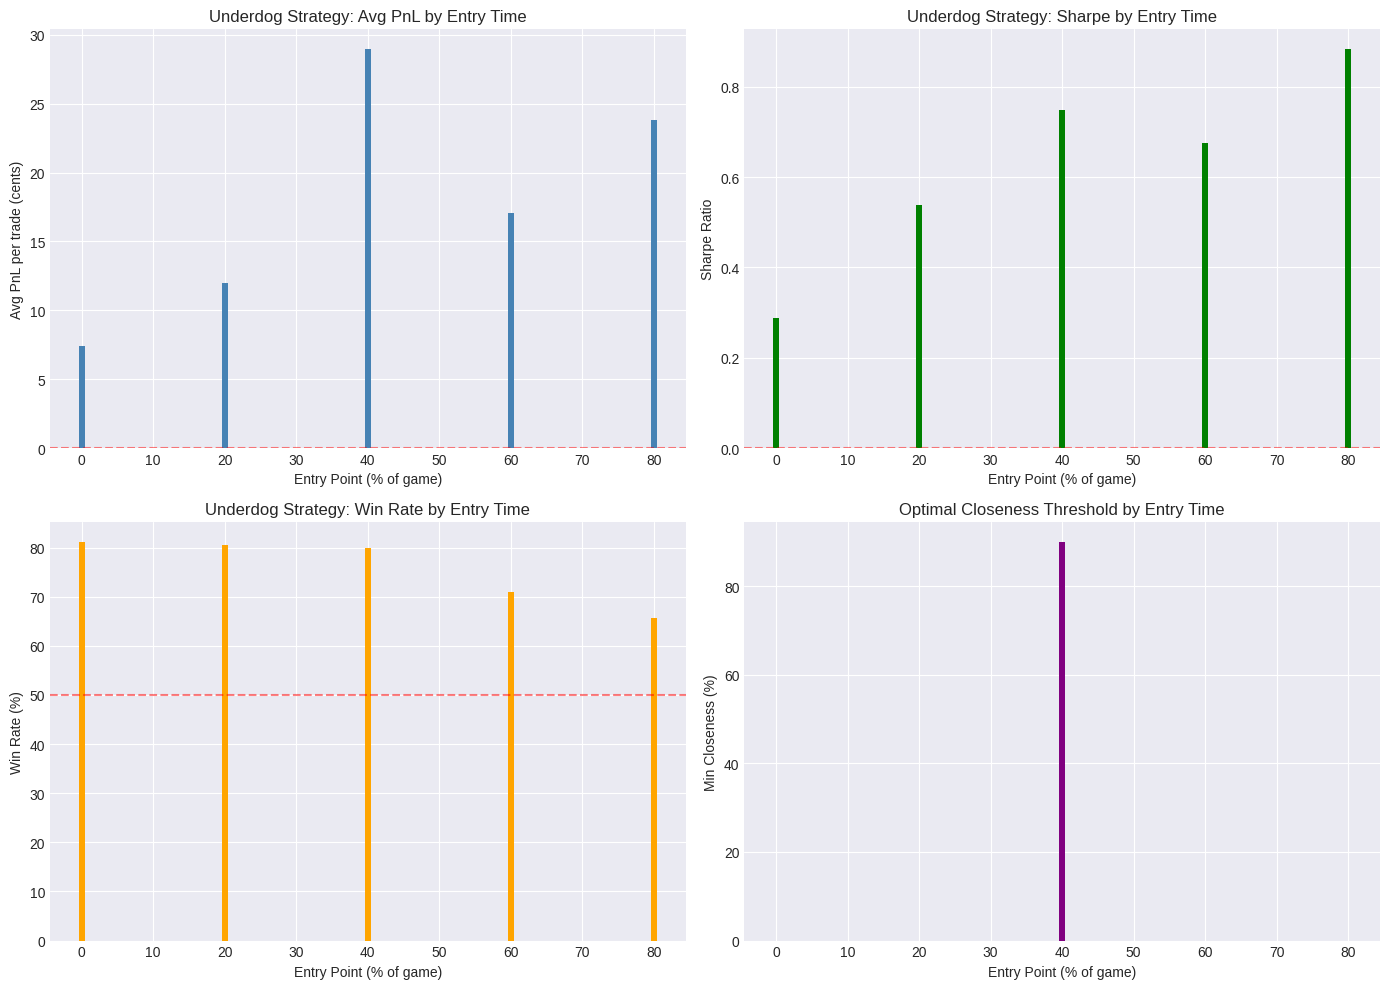

In [15]:
# Visualize best results by entry time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Avg PnL by entry time
ax = axes[0, 0]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['avg_pnl'] * 100, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Avg PnL per trade (cents)')
ax.set_title('Underdog Strategy: Avg PnL by Entry Time')

# 2. Sharpe by entry time
ax = axes[0, 1]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['sharpe'], color='green')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Underdog Strategy: Sharpe by Entry Time')

# 3. Win rate by entry time
ax = axes[1, 0]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['win_rate'] * 100, color='orange')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Underdog Strategy: Win Rate by Entry Time')

# 4. Optimal closeness by entry time
ax = axes[1, 1]
ax.bar(best_by_entry_df['entry_pct'], best_by_entry_df['min_closeness'] * 100, color='purple')
ax.set_xlabel('Entry Point (% of game)')
ax.set_ylabel('Min Closeness (%)')
ax.set_title('Optimal Closeness Threshold by Entry Time')

plt.tight_layout()
plt.show()

## 6. Heatmaps: Stop Loss vs Take Profit

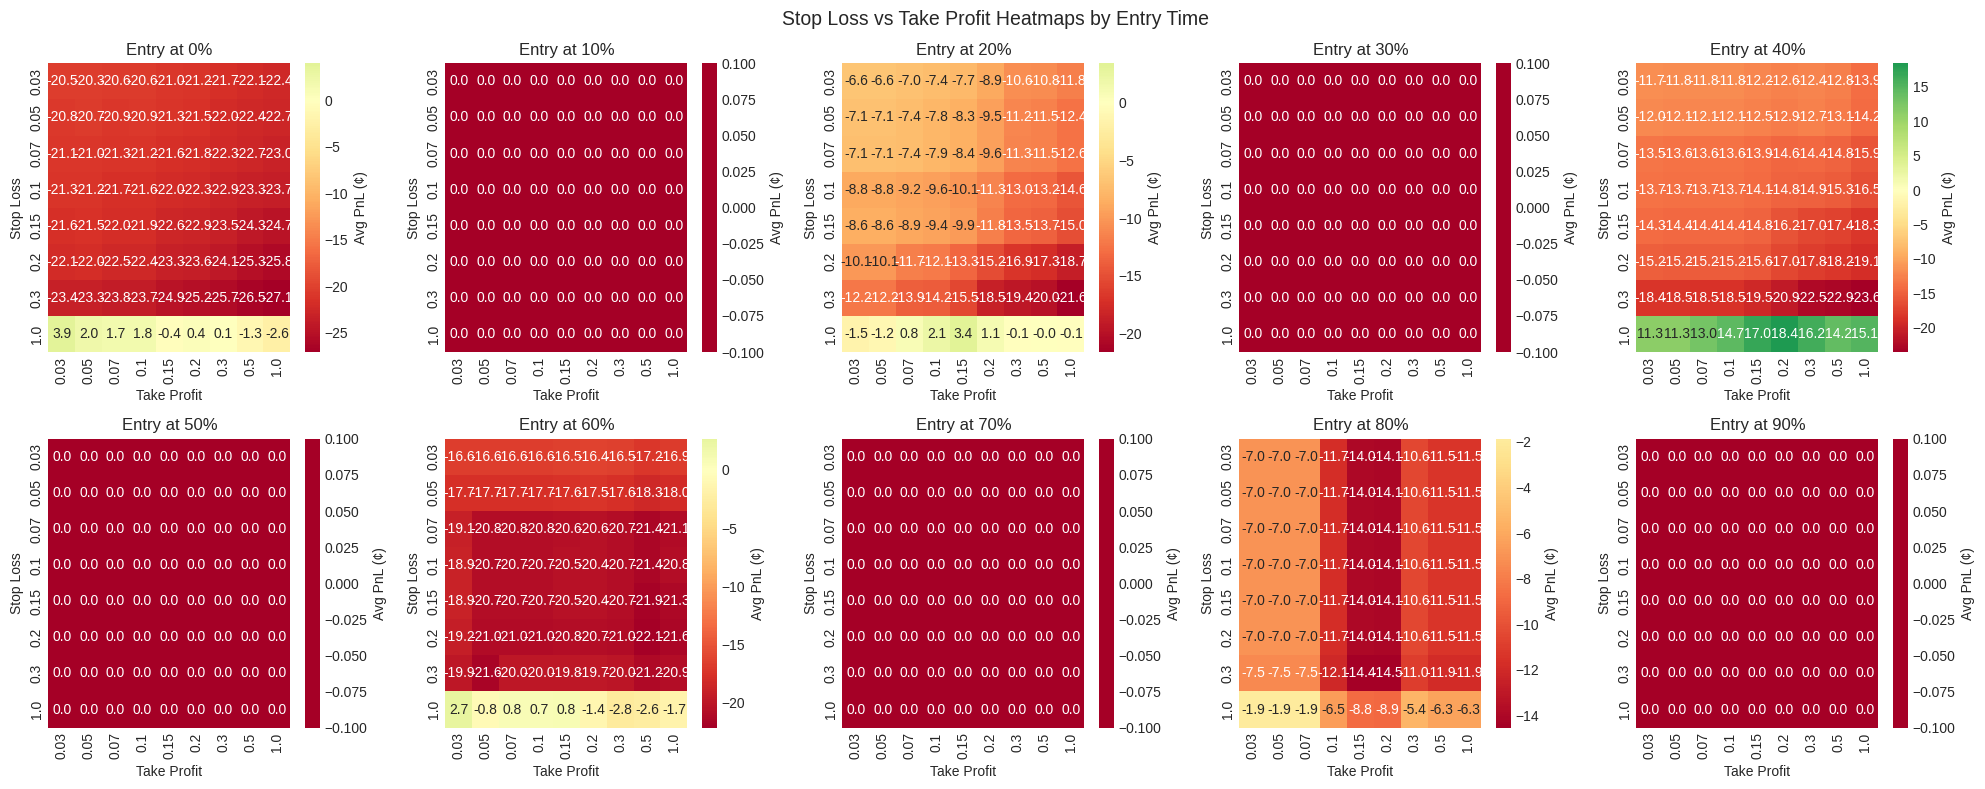

In [16]:
# Create heatmaps for each entry point
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, entry_pct in enumerate(ENTRY_PCTS):
    # Get data for this entry point, aggregate over closeness
    subset = results_df[results_df['entry_pct'] == entry_pct]
    pivot = subset.groupby(['stop_loss', 'take_profit'])['avg_pnl'].mean().unstack()
    
    ax = axes[idx]
    sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
                ax=ax, cbar_kws={'label': 'Avg PnL (¢)'})
    ax.set_title(f'Entry at {entry_pct}%')
    ax.set_xlabel('Take Profit')
    ax.set_ylabel('Stop Loss')

plt.suptitle('Stop Loss vs Take Profit Heatmaps by Entry Time', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Closeness Analysis

CLOSENESS THRESHOLD ANALYSIS (Aggregated across all entry times)
               n_trades  avg_pnl  win_rate  sharpe
min_closeness                                     
0.0                77.2   0.0088    0.1884 -0.0083
0.2                44.6  -0.0373    0.1604 -0.2299
0.4                32.5  -0.0611    0.1380 -0.3543
0.6                23.5  -0.0802    0.1137 -0.4841
0.7                18.0  -0.0893    0.1063 -0.5507
0.8                12.2  -0.0982    0.0883 -0.7013
0.9                 5.3  -0.1193    0.0417 -1.2095


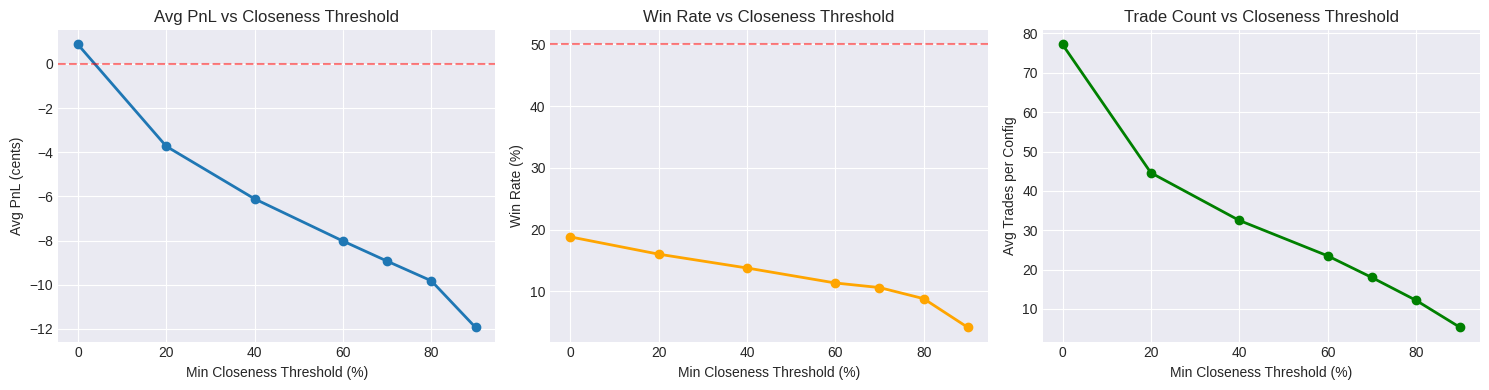

In [17]:
# Aggregate analysis: what closeness threshold works best overall?
print("=" * 80)
print("CLOSENESS THRESHOLD ANALYSIS (Aggregated across all entry times)")
print("=" * 80)

closeness_agg = results_df.groupby('min_closeness').agg({
    'n_trades': 'mean',
    'avg_pnl': 'mean',
    'win_rate': 'mean',
    'sharpe': 'mean',
}).round(4)

print(closeness_agg)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(closeness_agg.index * 100, closeness_agg['avg_pnl'] * 100, 'o-', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Min Closeness Threshold (%)')
ax.set_ylabel('Avg PnL (cents)')
ax.set_title('Avg PnL vs Closeness Threshold')

ax = axes[1]
ax.plot(closeness_agg.index * 100, closeness_agg['win_rate'] * 100, 'o-', linewidth=2, color='orange')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Min Closeness Threshold (%)')
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate vs Closeness Threshold')

ax = axes[2]
ax.plot(closeness_agg.index * 100, closeness_agg['n_trades'], 'o-', linewidth=2, color='green')
ax.set_xlabel('Min Closeness Threshold (%)')
ax.set_ylabel('Avg Trades per Config')
ax.set_title('Trade Count vs Closeness Threshold')

plt.tight_layout()
plt.show()

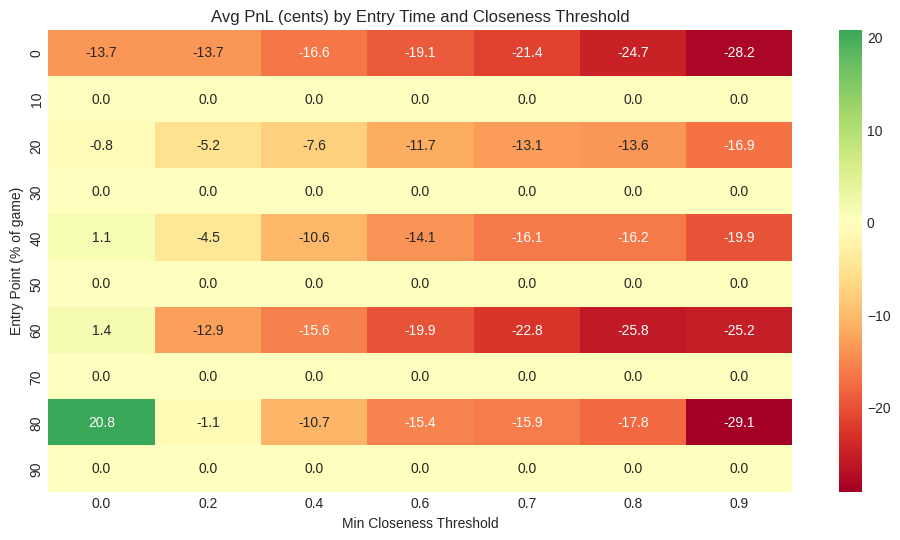

In [18]:
# Deep dive: closeness by entry time
pivot_closeness = results_df.pivot_table(
    values='avg_pnl',
    index='entry_pct',
    columns='min_closeness',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_closeness * 100, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.xlabel('Min Closeness Threshold')
plt.ylabel('Entry Point (% of game)')
plt.title('Avg PnL (cents) by Entry Time and Closeness Threshold')
plt.show()

## 8. Overall Best Parameters

In [19]:
# Filter to reasonable trade count
valid = results_df[results_df['n_trades'] >= 20]

print("=" * 80)
print("TOP 20 PARAMETER COMBINATIONS (by Sharpe Ratio)")
print("=" * 80)

top_20 = valid.nlargest(20, 'sharpe')[[
    'entry_pct', 'stop_loss', 'take_profit', 'min_closeness',
    'n_trades', 'avg_pnl', 'win_rate', 'sharpe'
]]
top_20['avg_pnl_cents'] = top_20['avg_pnl'] * 100
top_20['win_rate_pct'] = top_20['win_rate'] * 100
print(top_20.to_string())

TOP 20 PARAMETER COMBINATIONS (by Sharpe Ratio)
      entry_pct  stop_loss  take_profit  min_closeness  n_trades   avg_pnl  win_rate    sharpe  avg_pnl_cents  win_rate_pct
4473         80       1.00         0.03            0.0       154  0.238085  0.655844  0.883034      23.808506     65.584416
4480         80       1.00         0.05            0.0       154  0.238085  0.655844  0.883034      23.808506     65.584416
4487         80       1.00         0.07            0.0       154  0.238085  0.655844  0.883034      23.808506     65.584416
4494         80       1.00         0.10            0.0       154  0.234859  0.649351  0.854430      23.485877     64.935065
4501         80       1.00         0.15            0.0       154  0.231637  0.642857  0.827663      23.163701     64.285714
4515         80       1.00         0.30            0.0       154  0.237483  0.636364  0.826477      23.748279     63.636364
4508         80       1.00         0.20            0.0       154  0.231444  0.636364

In [20]:
# Top by total PnL
print("\n" + "=" * 80)
print("TOP 20 PARAMETER COMBINATIONS (by Total PnL)")
print("=" * 80)

top_pnl = valid.nlargest(20, 'total_pnl')[[
    'entry_pct', 'stop_loss', 'take_profit', 'min_closeness',
    'n_trades', 'total_pnl', 'avg_pnl', 'win_rate', 'sharpe'
]]
top_pnl['total_pnl_dollars'] = top_pnl['total_pnl']
print(top_pnl.to_string())


TOP 20 PARAMETER COMBINATIONS (by Total PnL)
      entry_pct  stop_loss  take_profit  min_closeness  n_trades  total_pnl   avg_pnl  win_rate    sharpe  total_pnl_dollars
4473         80       1.00         0.03            0.0       154   36.66510  0.238085  0.655844  0.883034           36.66510
4480         80       1.00         0.05            0.0       154   36.66510  0.238085  0.655844  0.883034           36.66510
4487         80       1.00         0.07            0.0       154   36.66510  0.238085  0.655844  0.883034           36.66510
4515         80       1.00         0.30            0.0       154   36.57235  0.237483  0.636364  0.826477           36.57235
4494         80       1.00         0.10            0.0       154   36.16825  0.234859  0.649351  0.854430           36.16825
4522         80       1.00         0.50            0.0       154   36.08320  0.234306  0.629870  0.805074           36.08320
4529         80       1.00         1.00            0.0       154   36.08320  0.

## 9. EV Analysis: Raw Underdog Betting

RAW UNDERDOG EV (Hold to Settlement, No Stop/Take)


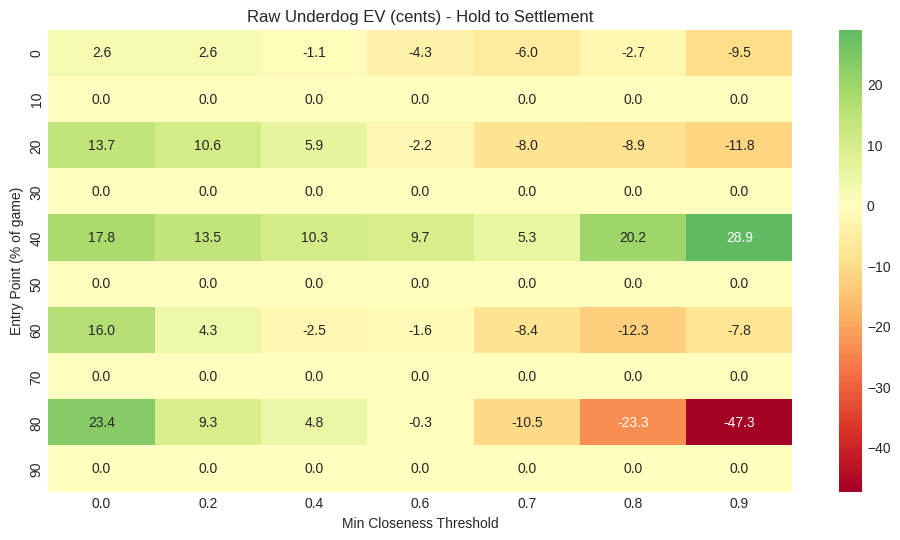

In [21]:
# What's the raw EV of betting on underdog (hold to settlement) at each time point?
print("=" * 80)
print("RAW UNDERDOG EV (Hold to Settlement, No Stop/Take)")
print("=" * 80)

raw_ev = []
for entry_pct in ENTRY_PCTS:
    for closeness in CLOSENESS_THRESHOLDS:
        # Simulate with no stop/take (just hold)
        stats = run_backtest(
            trajectories,
            entry_pct=entry_pct,
            stop_loss=1.0,  # Never trigger
            take_profit=1.0,  # Never trigger
            min_closeness=closeness,
        )
        raw_ev.append({
            'entry_pct': entry_pct,
            'min_closeness': closeness,
            **stats,
        })

raw_ev_df = pd.DataFrame(raw_ev)

# Pivot
pivot_raw = raw_ev_df.pivot_table(
    values='avg_pnl',
    index='entry_pct',
    columns='min_closeness',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_raw * 100, annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.xlabel('Min Closeness Threshold')
plt.ylabel('Entry Point (% of game)')
plt.title('Raw Underdog EV (cents) - Hold to Settlement')
plt.show()

In [22]:
# Summary table of raw EV
print("\nRaw EV Summary (closeness≥0.6, typical 'close game'):")
close_games = raw_ev_df[raw_ev_df['min_closeness'] >= 0.6]
summary = close_games.groupby('entry_pct').agg({
    'n_trades': 'mean',
    'avg_pnl': 'mean',
    'win_rate': 'mean',
}).round(4)
summary['ev_cents'] = summary['avg_pnl'] * 100
print(summary)


Raw EV Summary (closeness≥0.6, typical 'close game'):
           n_trades  avg_pnl  win_rate  ev_cents
entry_pct                                       
0             63.75  -0.0562    0.3981     -5.62
10             0.00   0.0000    0.0000      0.00
20            26.25  -0.0774    0.3700     -7.74
30             0.00   0.0000    0.0000      0.00
40            23.75   0.1602    0.6280     16.02
50             0.00   0.0000    0.0000      0.00
60            23.50  -0.0751    0.3830     -7.51
70             0.00   0.0000    0.0000      0.00
80            10.25  -0.2037    0.2418    -20.37
90             0.00   0.0000    0.0000      0.00


## 10. Summary and Recommendations

In [23]:
# Final summary
print("=" * 80)
print("FINAL RECOMMENDATIONS")
print("=" * 80)

# Best overall
best = valid.loc[valid['sharpe'].idxmax()]
print(f"\n🏆 BEST OVERALL (by Sharpe):")
print(f"   Entry: {best['entry_pct']}% of game")
print(f"   Stop Loss: {best['stop_loss']:.0%}")
print(f"   Take Profit: {best['take_profit']:.0%}")
print(f"   Min Closeness: {best['min_closeness']:.0%}")
print(f"   Trades: {best['n_trades']:.0f}")
print(f"   Avg PnL: {best['avg_pnl']*100:.2f} cents")
print(f"   Win Rate: {best['win_rate']:.1%}")
print(f"   Sharpe: {best['sharpe']:.3f}")

# Best by total profit
best_total = valid.loc[valid['total_pnl'].idxmax()]
print(f"\n💰 BEST BY TOTAL PROFIT:")
print(f"   Entry: {best_total['entry_pct']}% of game")
print(f"   Stop Loss: {best_total['stop_loss']:.0%}")
print(f"   Take Profit: {best_total['take_profit']:.0%}")
print(f"   Min Closeness: {best_total['min_closeness']:.0%}")
print(f"   Trades: {best_total['n_trades']:.0f}")
print(f"   Total PnL: ${best_total['total_pnl']:.2f}")
print(f"   Avg PnL: {best_total['avg_pnl']*100:.2f} cents")

# Recommended closeness (aggregate)
best_closeness = closeness_agg.loc[closeness_agg['avg_pnl'].idxmax()]
print(f"\n🎯 RECOMMENDED CLOSENESS THRESHOLD:")
print(f"   Min Closeness ≥ {best_closeness.name:.0%}")
print(f"   (Aggregated across all entry times and stop/take params)")

FINAL RECOMMENDATIONS

🏆 BEST OVERALL (by Sharpe):
   Entry: 80.0% of game
   Stop Loss: 100%
   Take Profit: 3%
   Min Closeness: 0%
   Trades: 154
   Avg PnL: 23.81 cents
   Win Rate: 65.6%
   Sharpe: 0.883

💰 BEST BY TOTAL PROFIT:
   Entry: 80.0% of game
   Stop Loss: 100%
   Take Profit: 3%
   Min Closeness: 0%
   Trades: 154
   Total PnL: $36.67
   Avg PnL: 23.81 cents

🎯 RECOMMENDED CLOSENESS THRESHOLD:
   Min Closeness ≥ 0%
   (Aggregated across all entry times and stop/take params)


In [24]:
# Save results
results_df.to_csv('../data/underdog_backtest_results.csv', index=False)
print(f"\n✅ Saved full results to data/underdog_backtest_results.csv")


✅ Saved full results to data/underdog_backtest_results.csv
